# docpipe by example — one scanned hospital bill

This notebook is the runnable twin of [`hospital_bill.py`](hospital_bill.py). It walks
the whole library over a single document, one capability per cell, and **every cell ends
with something you can look at** — a rendered page, a table, a set of boxes drawn on the
scan.

It runs **offline and for free**: no API key, no network, no OCR engine. The only
third-party packages it needs are **numpy** and **pillow**, because the bill is rendered
here, degraded here, and read by a stub backend that stands in for Tesseract.

```bash
pip install -e ".[notebook]"      # from the repo root: numpy, pillow, and Jupyter
```

If you already have a Jupyter set-up, `pip install numpy pillow` is genuinely all this
notebook adds.

**What you are about to see**

| | Section |
|---|---|
| 1 | The only part a project owns: schema, context, business rules |
| 2 | A synthetic bill, pushed through a realistically nasty channel |
| 3 | Ingest — bytes in, a `Document` out, nothing rasterised yet |
| 4 | Measure the damage before correcting any of it |
| 5 | What each preprocessing policy would do, and why they differ |
| 6 | Preprocess, and look at the before/after |
| 7 | The op toolbox: binarisation methods, deskew |
| 8 | Reading: spans, geometry, per-word confidence |
| 9 | Provenance — draw what the reader saw |
| 10 | Normalising Indian digit grouping and DD-MM-YYYY dates |
| 11 | Extraction: schema in, typed fields out |
| 12 | What a confidence number is actually made of |
| 13 | When a business rule fails, and the review queue that falls out of it |
| 14 | Evidence rectangles on the page |
| 15 | Extraction with no model at all |
| 16 | Token and cost accounting |
| 17 | The eval harness: did preprocessing actually help? |
| 18 | Everything is serialisable |

## Setup

`docpipe` is one file, so this is just an import. `Caps.capabilities()` reports what is
usable in *this* interpreter — the core needs nothing, and everything heavier is optional
and loaded at the point of use.

In [1]:
import decimal
import io
import json
import os
import re
import sys
import tempfile

import numpy as np

# Find docpipe.py whether this notebook is opened from the repo root or examples/.
# An installed copy (pip install docpipe-core) works too, from anywhere.
for _candidate in (os.getcwd(), os.path.dirname(os.getcwd())):
    if os.path.exists(os.path.join(_candidate, "docpipe.py")):
        sys.path.insert(0, _candidate)
        break

try:
    import docpipe as dp
except ImportError:
    raise ImportError(
        "docpipe not found. Open this notebook from inside the repository "
        "(the folder holding docpipe.py, or examples/ beside it), or run "
        "`pip install docpipe-core`.")

print("docpipe %s   |   Python %s" % (dp.__version__, sys.version.split()[0]))
print()
caps = dp.Caps.capabilities()
for name in sorted(caps):
    print("  %-20s %s" % (name, "available" if caps[name] else "-"))
print()
print("backends registered: %s" % ", ".join(dp.registry.names()))

docpipe 0.1.0   |   Python 3.10.12

  PIL                  available
  anthropic            -
  cv2                  -
  doctr                -
  easyocr              -
  numpy                available
  openai               -
  opencv_enabled       -
  paddleocr            -
  pydantic             -
  pymupdf              -
  pypdfium2            -
  pytesseract          -
  rapidocr_onnxruntime -
  surya                -
  tesseract_binary     -

backends registered: doctr, easyocr, paddle, pymupdf, rapidocr, surya, tesseract, vlm:claude, vlm:gemini, vlm:openai


### Two display helpers

Everything below prints through these, so each cell has a visible result. `show_image`
renders inline in Jupyter and degrades to writing a PNG when the notebook is executed as a
plain script.

In [2]:
from PIL import Image as PILImage, ImageDraw, ImageFont


def show_image(img, title="", max_width=760):
    """Display a raster inline.  Outside a notebook, write a PNG and print the path.

    Emits PNG explicitly rather than handing the PIL object to `display`, which
    would store a redundant JPEG copy of every image in the saved notebook.
    """
    arr = dp.Image.ensure_uint8(np.asarray(img))
    pil = PILImage.fromarray(arr)
    if title:
        print("%s  --  %d x %d px" % (title, arr.shape[1], arr.shape[0]))
    if pil.width > max_width:
        pil = pil.resize((max_width, int(pil.height * (float(max_width) / pil.width))))
    buffer = io.BytesIO()
    pil.save(buffer, format="PNG", optimize=True)
    try:
        from IPython.display import display, Image as InlineImage
    except ImportError:
        path = os.path.join(tempfile.gettempdir(),
                            "%s.png" % (title.replace(" ", "_").replace("/", "_") or "img"))
        pil.save(path)
        print("  (not in a notebook -- wrote %s)" % path)
        return
    display(InlineImage(data=buffer.getvalue(), format="png"))


def show_row(images, titles=(), max_width=880, gap=14):
    """Display several rasters side by side, so a before/after is one glance."""
    arrays = [dp.Image.to_rgb(dp.Image.ensure_uint8(np.asarray(i))) for i in images]
    height = max(a.shape[0] for a in arrays)
    width = sum(a.shape[1] for a in arrays) + gap * (len(arrays) - 1)
    canvas = np.full((height, width, 3), 255, dtype=np.uint8)
    x = 0
    for a in arrays:
        canvas[0:a.shape[0], x:x + a.shape[1]] = a
        x += a.shape[1] + gap
    if titles:
        print(" | ".join(titles))
    show_image(canvas, max_width=max_width)


def show_table(headers, rows):
    """Print an aligned text table.  Works in a notebook, a terminal and a diff."""
    rows = [[("-" if c is None else str(c)) for c in row] for row in rows]
    widths = [len(str(h)) for h in headers]
    for row in rows:
        for i, cell in enumerate(row):
            widths[i] = max(widths[i], len(cell))
    line = "  ".join(str(h).ljust(widths[i]) for i, h in enumerate(headers))
    print(line)
    print("  ".join("-" * w for w in widths))
    for row in rows:
        print("  ".join(cell.ljust(widths[i]) for i, cell in enumerate(row)))


def bar(value, width=22):
    """A crude horizontal bar, for reading a 0..1 metric at a glance."""
    filled = int(round(max(0.0, min(1.0, value)) * width))
    return "#" * filled + "." * (width - filled)


show_table(["helper", "what it gives you"],
           [["show_image(img)", "one raster, inline"],
            ["show_row([a, b])", "several rasters side by side"],
            ["show_table(h, rows)", "an aligned text table"],
            ["bar(0.42)", bar(0.42)]])

helper               what it gives you           
-------------------  ----------------------------
show_image(img)      one raster, inline          
show_row([a, b])     several rasters side by side
show_table(h, rows)  an aligned text table       
bar(0.42)            #########.............      


## 1. The only part a project owns

A schema, a sentence of context, and the business rules. That is the entire domain-side
surface — everything after this cell is library, and none of it knows what a hospital bill
is.

The schema here is a plain dict, so this cell needs no pydantic. A pydantic model or a
dataclass works exactly the same way and gives you a typed object back in `result.model`.

In [3]:
BILL_SCHEMA = {
    "hospital_name": {"type": "string", "description": "name of the hospital"},
    "patient_name": {"type": "string"},
    "bill_number": {"type": "string", "description": "invoice or bill number"},
    "admission_date": {"type": "date"},
    "discharge_date": {"type": "date", "required": False},
    "gross_amount": {"type": "number"},
    "discount": {"type": "number", "required": False},
    "total": {"type": "number", "description": "final amount payable"},
}

CONTEXT = (
    "Indian private hospital final bill. Amounts are in INR and may use Indian "
    "digit grouping (1,23,456.78). Dates are usually DD-MM-YYYY."
)

adapter = dp.SchemaAdapter.from_schema(BILL_SCHEMA)
show_table(["field", "type", "required", "description"],
           [[f.name, f.type_name, "yes" if f.required else "optional", f.description or "-"]
            for f in adapter.fields])
print()
print("context passed to the model:")
print("  " + CONTEXT)

field           type    required  description           
--------------  ------  --------  ----------------------
hospital_name   string  yes       name of the hospital  
patient_name    string  yes       -                     
bill_number     string  yes       invoice or bill number
admission_date  date    yes       -                     
discharge_date  date    optional  -                     
gross_amount    number  yes       -                     
discount        number  optional  -                     
total           number  yes       final amount payable  

context passed to the model:
  Indian private hospital final bill. Amounts are in INR and may use Indian digit grouping (1,23,456.78). Dates are usually DD-MM-YYYY.


### The business rules

A validator takes the extracted data and returns a `ValidationIssue` or `None`. Its job is
not only to complain: **a failed validator pulls that field's confidence down**, which is
how a broken bill ends up in the review queue in section 13 without anyone writing routing
code.

In [4]:
def gross_minus_discount_is_total(bill):
    """Domain arithmetic: the two amounts on the page must reconcile."""
    gross = bill.get("gross_amount")
    discount = bill.get("discount") or decimal.Decimal(0)
    total = bill.get("total")
    if gross is None or total is None:
        return None
    if abs((gross - discount) - total) > decimal.Decimal("1.00"):
        return dp.ValidationIssue(
            "gross %s minus discount %s is not total %s" % (gross, discount, total),
            fields=["gross_amount", "discount", "total"])
    return None


VALIDATORS = [
    gross_minus_discount_is_total,
    dp.Validators.date_order("admission_date", "discharge_date"),
    dp.Validators.field_matches("bill_number", r"\w"),
    dp.Validators.required_fields("hospital_name", "total"),
]

show_table(["rule", "kind", "what it catches"],
           [["gross_minus_discount_is_total", "yours", "the amounts do not reconcile"],
            ["date_order", "library", "discharge before admission"],
            ["field_matches", "library", "an empty or junk bill number"],
            ["required_fields", "library", "a field the document must carry"]])

rule                           kind     what it catches                
-----------------------------  -------  -------------------------------
gross_minus_discount_is_total  yours    the amounts do not reconcile   
date_order                     library  discharge before admission     
field_matches                  library  an empty or junk bill number   
required_fields                library  a field the document must carry


## 2. A synthetic bill, and a realistically nasty channel

A scanned page is *a fact that survived a noisy channel*: printed, photocopied, lit
unevenly, photographed slightly out of focus, and saved at whatever resolution the scanner
defaulted to. So we render a clean bill, then break it on purpose — that way the ground
truth is known exactly.

While drawing, we record **the true bounding box of every word**. That is the same trick
the test suite uses, and it means the provenance boxes later in this notebook are exact
rather than decorative.

63 words recorded with exact geometry
word             box (x0, y0, x1, y1)  line
---------------  --------------------  ----
SUNRISE            70   66  184   85   0   
MULTISPECIALITY   193   66  415   85   0   
HOSPITAL          424   66  551   85   0   
12                 70  108  103  127   1   
Nehru             112  107  191  127   1   
Road,             200  107  274  130   1   
the bill as printed  --  1240 x 1200 px


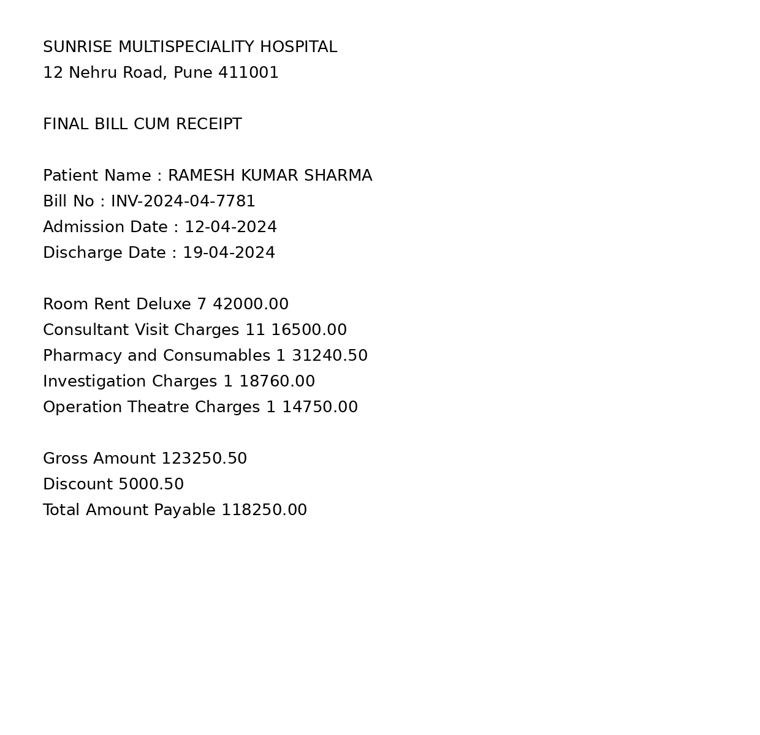

In [5]:
BILL_TEXT = [
    "SUNRISE MULTISPECIALITY HOSPITAL",
    "12 Nehru Road, Pune 411001",
    "",
    "FINAL BILL CUM RECEIPT",
    "",
    "Patient Name : RAMESH KUMAR SHARMA",
    "Bill No : INV-2024-04-7781",
    "Admission Date : 12-04-2024",
    "Discharge Date : 19-04-2024",
    "",
    "Room Rent Deluxe                  7      42000.00",
    "Consultant Visit Charges         11      16500.00",
    "Pharmacy and Consumables          1      31240.50",
    "Investigation Charges             1      18760.00",
    "Operation Theatre Charges         1      14750.00",
    "",
    "Gross Amount                           123250.50",
    "Discount                                 5000.50",
    "Total Amount Payable                   118250.00",
]


def render_bill():
    """Draw the bill and record the true pixel box of every word as we go."""
    image = PILImage.new("L", (1240, 1200), 255)
    draw = ImageDraw.Draw(image)
    try:
        font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 26)
    except Exception:
        font = ImageFont.load_default()

    boxes = []
    y = 60
    for line_no, line in enumerate(BILL_TEXT):
        x = 70
        for word in line.split():
            draw.text((x, y), word, fill=0, font=font)
            box = draw.textbbox((x, y), word, font=font)
            boxes.append((word, box, line_no))
            x = box[2] + 9
        y += 42
    return np.array(image), boxes


CLEAN, WORD_BOXES = render_bill()
CLEAN_SIZE = (CLEAN.shape[1], CLEAN.shape[0])

print("%d words recorded with exact geometry" % len(WORD_BOXES))
show_table(["word", "box (x0, y0, x1, y1)", "line"],
           [[w, "%4d %4d %4d %4d" % b, ln] for w, b, ln in WORD_BOXES[:6]])
show_image(CLEAN, "the bill as printed")

### Now break it

Four independent degradations, each modelling something real. Look at the filmstrip: by
the last frame the page is genuinely hard to read, and that is the input the rest of the
notebook works from.

stage           models                                      size       
--------------  ------------------------------------------  -----------
as printed      the original document                       1240 x 1200
uneven light    a page lit from one side, or a phone photo  1240 x 1200
soft focus      a scanner slightly out of focus             1240 x 1200
sensor noise    a cheap sensor at low light                 1240 x 1200
low resolution  a flatbed left on its default DPI           682 x 660  
as printed | uneven light | soft focus | sensor noise | low resolution


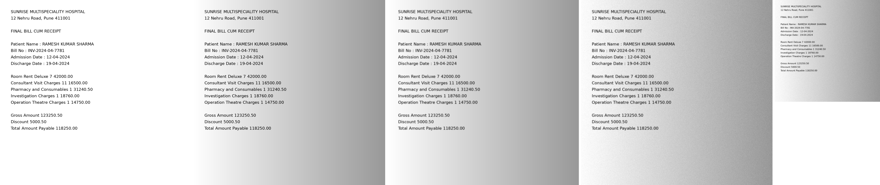

In [6]:
stages = [("as printed", CLEAN)]

shadowed = CLEAN.astype(float) * np.linspace(1.0, 0.6, CLEAN.shape[1])[None, :]
shadowed = dp.Image.ensure_uint8(shadowed)
stages.append(("uneven light", shadowed))

blurred = dp.Image.gaussian_blur(shadowed, 1.1)
stages.append(("soft focus", blurred))

noisy = blurred.astype(float) + np.random.RandomState(0).normal(0, 9, blurred.shape)
noisy = dp.Image.ensure_uint8(np.clip(noisy, 0, 255))
stages.append(("sensor noise", noisy))

SCAN = dp.Image.resize_image(noisy, scale=0.55)
stages.append(("low resolution", SCAN))

show_table(["stage", "models", "size"],
           [[name, reason, "%d x %d" % (img.shape[1], img.shape[0])]
            for (name, img), reason in zip(stages, [
                "the original document",
                "a page lit from one side, or a phone photo",
                "a scanner slightly out of focus",
                "a cheap sensor at low light",
                "a flatbed left on its default DPI"])])
show_row([s[1] for s in stages], titles=[s[0] for s in stages])

## 3. Ingest

`Ingest.ingest` takes a path, raw bytes or a file object, sniffs the format, and returns a
`Document`. PDFs, images, multi-page TIFFs and `.eml` files all arrive the same way.

Notice what it does **not** do: it does not rasterise. Pages carry a lazy raster provider,
because a 300-page bundle rendered eagerly at 400 DPI is tens of gigabytes of RAM. The
pixels appear the first time something asks for them.

In [7]:
doc = dp.Ingest.ingest(dp.Image.encode_png(SCAN), filename="bill.png", dpi=150)
page = doc.pages[0]

show_table(["property", "value", "why it matters"], [
    ["document", str(doc), "one page, source recorded"],
    ["page.kind", page.kind.value, "SCANNED -- there is no text layer to reuse"],
    ["page size (pt)", "%.0f x %.0f" % (page.width_pt, page.height_pt), "geometry in PDF points"],
    ["page.raster_dpi", page.raster_dpi, "0 until something asks for pixels"],
    ["page.has_raster()", page.has_raster(), "True: it *can* render, not that it has"],
    ["doc.char_count", doc.char_count, "nothing read yet"],
])
print()
print("first raster() call materialises the pixels:")
print("  %s at %d dpi" % (page.raster().shape, page.raster_dpi))

property           value                                   why it matters                            
-----------------  --------------------------------------  ------------------------------------------
document           Document('bill.png', pages=1, chars=0)  one page, source recorded                 
page.kind          scanned                                 SCANNED -- there is no text layer to reuse
page size (pt)     327 x 317                               geometry in PDF points                    
page.raster_dpi    150                                     0 until something asks for pixels         
page.has_raster()  True                                    True: it *can* render, not that it has    
doc.char_count     0                                       nothing read yet                          

first raster() call materialises the pixels:
  (660, 682) at 150 dpi


## 4. Measure the damage before correcting any of it

This is the step people skip, and skipping it is why fixed preprocessing pipelines
under-perform. Preprocessing is *channel equalisation*: the right correction for a page is
a function of that page's measured degradation. Sharpen a page that was never blurred and
you destroy signal that was intact.

Every metric is normalised to 0–1 (except skew, in degrees) so the thresholds are portable
across scanners.

In [8]:
dp.Quality.measure_document(doc)
q = doc.pages[0].quality

show_table(["metric", "value", "", "reading"], [
    ["blur", "%.2f" % q.blur, bar(q.blur), "1.0 is razor sharp"],
    ["contrast", "%.2f" % q.contrast, bar(q.contrast), "ink against paper"],
    ["illumination", "%.2f" % q.illumination, bar(q.illumination), "1.0 is evenly lit"],
    ["noise", "%.2f" % q.noise, bar(q.noise), "lower is better"],
    ["ink_coverage", "%.3f" % q.ink_coverage, bar(q.ink_coverage), "how much of the page is ink"],
    ["skew_deg", "%.2f" % q.skew_deg, "", "degrees off horizontal"],
    ["effective_dpi", q.effective_dpi, "", "measured, not what the file claims"],
    ["raster_dpi", q.raster_dpi, "", "what the file claims"],
])
print()
print("verdict: %s      overall score: %.2f  %s" % (q.verdict.value, q.score, bar(q.score)))
print("readable without help? %s" % q.is_readable)

metric         value                          reading                           
-------------  -----  ----------------------  ----------------------------------
blur           0.48   ###########...........  1.0 is razor sharp                
contrast       0.24   #####.................  ink against paper                 
illumination   0.33   #######...............  1.0 is evenly lit                 
noise          0.25   ######................  lower is better                   
ink_coverage   0.040  #.....................  how much of the page is ink       
skew_deg       0.00                           degrees off horizontal            
effective_dpi  269                            measured, not what the file claims
raster_dpi     150                            what the file claims              

verdict: degraded      overall score: 0.56  ############..........
readable without help? True


## 5. What would each policy do?

A policy is a function from a measured page to the list of ops it needs. Three ship, and
the difference between them is a real finding rather than a preference:

**`ocr_policy` binarises. `vlm_policy` never does.** Hard black-on-white reliably helps
classical OCR and reliably *hurts* vision models, which use the grey gradient to resolve
faint strokes that a threshold has already destroyed. `default_policy` therefore leaves
binarisation out, so it is safe for either reader.

In [9]:
page = doc.pages[0]
policies = [
    ("default_policy", dp.Policies.default_policy(page)),
    ("ocr_policy", dp.Policies.ocr_policy(page)),
    ("vlm_policy", dp.Policies.vlm_policy(page)),
    ("no_policy", dp.Policies.no_policy(page)),
]

show_table(["policy", "ops it would apply to *this* page"],
           [[name, " -> ".join(o.name for o in ops) or "nothing"] for name, ops in policies])
print()
print("each op is data, not code -- so a policy can be recorded and replayed exactly:")
op = dp.Policies.default_policy(page)[0]
print("  %r" % op)
print("  to_dict:   %s" % op.to_dict())
print("  round trip: %r" % dp.op_from_dict(op.to_dict()))

policy          ops it would apply to *this* page                                                                   
--------------  ----------------------------------------------------------------------------------------------------
default_policy  normalize_illumination -> ensure_dpi -> autocontrast                                                
ocr_policy      normalize_illumination -> ensure_dpi -> autocontrast -> to_grayscale -> binarize -> despeckle -> pad
vlm_policy      normalize_illumination -> autocontrast -> resize_max_side                                           
no_policy       nothing                                                                                             

each op is data, not code -- so a policy can be recorded and replayed exactly:
  Op(normalize_illumination, radius=None, strength=1.0)
  to_dict:   {'op': 'normalize_illumination', 'params': {'radius': None, 'strength': 1.0}}
  round trip: Op(normalize_illumination, radius=None, strength=1.0)


## 6. Preprocess, and look at the result

`preprocess` measures, asks the policy what this page needs, applies exactly that, and
records every step in `page.history` — which is what later lets an accuracy change be
attributed to a specific op.

metric         before    after  change
-------------  --------  -----  ------
blur           0.48      0.51   +0.03 
contrast       0.24      0.68   +0.45 
illumination   0.33      0.85   +0.52 
effective_dpi  269       318    +49   
score          0.56      0.74   +0.18 
verdict        degraded  clean        

history: measure_quality(dpi=150) -> measure_quality(dpi=150) -> normalize_illumination(radius=None, strength=1.0) -> ensure_dpi(interpolation='auto', max_dpi=600, min_dpi=300) -> autocontrast(high_pct=99.0, low_pct=1.0) -> measure_quality(dpi=167)
before | after


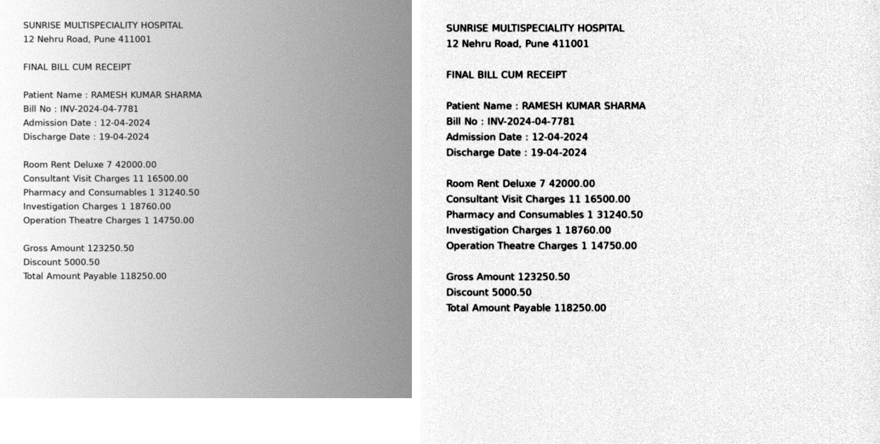

In [10]:
before_img = doc.pages[0].raster().copy()
before_q = doc.pages[0].quality

doc = dp.preprocess(doc, policy=dp.Policies.default_policy)
after_q = doc.pages[0].quality
after_img = doc.pages[0].raster()

show_table(["metric", "before", "after", "change"], [
    ["blur", "%.2f" % before_q.blur, "%.2f" % after_q.blur, "%+.2f" % (after_q.blur - before_q.blur)],
    ["contrast", "%.2f" % before_q.contrast, "%.2f" % after_q.contrast, "%+.2f" % (after_q.contrast - before_q.contrast)],
    ["illumination", "%.2f" % before_q.illumination, "%.2f" % after_q.illumination, "%+.2f" % (after_q.illumination - before_q.illumination)],
    ["effective_dpi", before_q.effective_dpi, after_q.effective_dpi, "%+d" % (after_q.effective_dpi - before_q.effective_dpi)],
    ["score", "%.2f" % before_q.score, "%.2f" % after_q.score, "%+.2f" % (after_q.score - before_q.score)],
    ["verdict", before_q.verdict.value, after_q.verdict.value, ""],
])
print()
print("history: %s" % doc.pages[0].history_summary())
show_row([before_img, after_img], titles=["before", "after"])

## 7. The op toolbox

Twenty-odd ops ship. Two worth seeing directly, because they are the ones people reach for
and get wrong.

### Binarisation, seven ways

All of these are integral-image based, so the cost does not grow with the window size.
`sauvola` is the default because it survives uneven lighting, which is the common failure
of plain `otsu` on a photographed page.

In [11]:
crop = dp.Image.to_gray(after_img)[40:150, :]
methods = ["otsu", "adaptive", "sauvola", "niblack"]
show_row([crop] + [dp.Ops.binarize_array(crop, method=m) for m in methods],
         titles=["greyscale"] + methods)
print()
print("also available: wolf, nick, bradley")
print("remember: binarise for classical OCR, never for a vision model.")

greyscale | otsu | adaptive | sauvola | niblack



also available: wolf, nick, bradley
remember: binarise for classical OCR, never for a vision model.


### Deskew, and how well the measurement recovers a known angle

The scan above happens to be straight. So tilt a page by a known amount and check that the
estimator finds it — this is exactly how the test suite asserts the measurement is real
rather than plausible. `skew_deg` is reported as *the rotation needed to correct the page*,
so tilting by -2.4° is measured as +2.4°.

              true tilt  measured correction  error   
------------  ---------  -------------------  --------
tilted page   -2.40 deg  +2.40 deg            0.00 deg
after deskew  0.00 deg   +0.00 deg            0.00 deg
crooked | deskewed


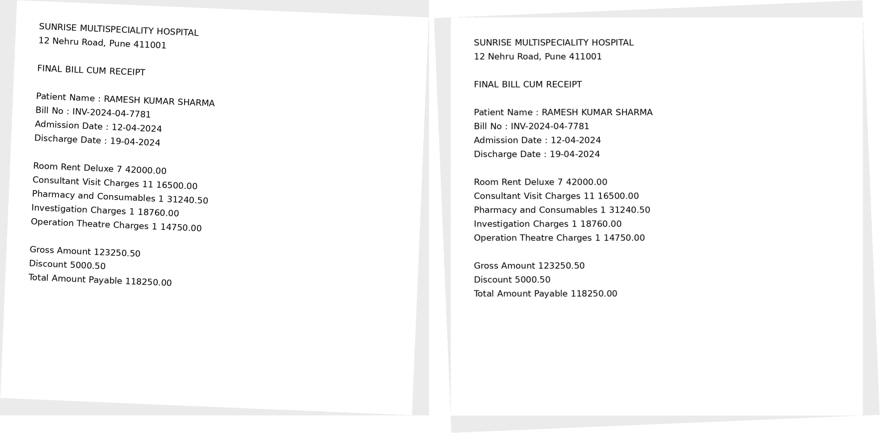

In [12]:
TILT = -2.4
tilted = dp.Image.rotate_image(CLEAN, TILT, border_value=235)
measured = dp.Quality.estimate_skew(dp.Image.to_gray(tilted))

tilted_doc = dp.Ingest.document_from_images([tilted], dpi=150)
tilted_doc = dp.preprocess(tilted_doc, policy=dp.Policies.fixed_policy(dp.Ops.deskew()))
straightened = tilted_doc.pages[0].raster()
residual = dp.Quality.estimate_skew(dp.Image.to_gray(straightened))

show_table(["", "true tilt", "measured correction", "error"],
           [["tilted page", "%.2f deg" % TILT, "%+.2f deg" % measured,
             "%.2f deg" % abs(abs(TILT) - abs(measured))],
            ["after deskew", "0.00 deg", "%+.2f deg" % residual, "%.2f deg" % abs(residual)]])
show_row([tilted, straightened], titles=["crooked", "deskewed"])

## 8. Reading

A backend consumes a `Page` and produces `TextSpan`s — text plus the rectangle it sits in.
That is the entire contract, and it is what makes backends interchangeable: a router picks
one per page, an ensemble runs two and compares, and the eval harness can A/B whole
pipelines because the types line up.

The stub below stands in for Tesseract so this notebook needs no OCR install. It is honest
in two ways that matter:

- it returns **the true geometry** we recorded while drawing, scaled to whatever raster it
  is handed, so every box below is real;
- it **makes mistakes when the page is bad** — on a page the library still calls
  `degraded`, it mangles digits the way a real engine does. That is what makes the
  evaluation in section 17 mean something.

In [13]:
def mangle(word):
    """The digit confusions a real engine makes on a soft, low-contrast scan."""
    return word.replace("0", "O").replace("1", "l")


class StubOCR(dp.BaseBackend):
    """Stands in for Tesseract/Paddle: real geometry, quality-dependent mistakes."""

    name = "stub-ocr"
    preferred_dpi = 300

    def is_available(self):
        return True

    def supports(self, page):
        return True

    def _read(self, page):
        img = page.raster()
        sx = float(img.shape[1]) / CLEAN_SIZE[0]
        sy = float(img.shape[0]) / CLEAN_SIZE[1]
        legible = page.quality.verdict is dp.Verdict.CLEAN
        spans = []
        for word, (x0, y0, x1, y1), line_no in WORD_BOXES:
            text = word if legible else mangle(word)
            spans.append(dp.TextSpan(
                text=text,
                bbox=dp.BBox.from_pixels(page.index, x0 * sx, y0 * sy, x1 * sx, y1 * sy,
                                         page.raster_dpi),
                source=self.name,
                confidence=0.93 if legible else 0.61,
                line=line_no))
        return dp.ReadResult(spans=spans, cost=dp.Cost(calls=1), backend=self.name)


dp.registry.register("stub-ocr", lambda: StubOCR(), replace=True)

doc = dp.read(doc, backend="stub-ocr")
doc = dp.Text.normalize_document(doc, in_place=True)

print("read %d characters via %s" % (doc.char_count, doc.meta["read_backends"]))
print()
show_table(["text", "page", "x0", "y0", "x1", "y1", "conf", "source"],
           [[s.text, s.bbox.page, "%.0f" % s.bbox.x0, "%.0f" % s.bbox.y0,
             "%.0f" % s.bbox.x1, "%.0f" % s.bbox.y1, "%.2f" % s.confidence, s.source]
            for s in doc.pages[0].spans[:8]])
print()
print("reading-order text, lines regrouped from the geometry:")
for line in doc.pages[0].lines()[:6]:
    print("  " + line)

read 380 characters via {0: 'stub-ocr'}

text             page  x0   y0  x1   y1  conf  source  
---------------  ----  ---  --  ---  --  ----  --------
SUNRISE          0     19   17  49   22  0.93  stub-ocr
MULTISPECIALITY  0     51   17  110  22  0.93  stub-ocr
HOSPITAL         0     112  17  146  22  0.93  stub-ocr
12               0     19   29  27   34  0.93  stub-ocr
Nehru            0     30   28  51   34  0.93  stub-ocr
Road,            0     53   28  72   34  0.93  stub-ocr
Pune             0     75   29  92   34  0.93  stub-ocr
411001           0     94   29  120  34  0.93  stub-ocr

reading-order text, lines regrouped from the geometry:
  SUNRISE MULTISPECIALITY HOSPITAL
  12 Nehru Road, Pune 411001
  FINAL BILL CUM RECEIPT
  Patient Name : RAMESH KUMAR SHARMA
  Bill No : INV-2024-04-7781
  Admission Date : 12-04-2024


## 9. Provenance — draw what the reader saw

Spans carry geometry so a value can always be traced back to a rectangle on a page.
`BBox.to_pixels(dpi)` converts back into the current raster's pixel space, which is all a
review UI needs.

every span the backend returned  --  761 x 736 px


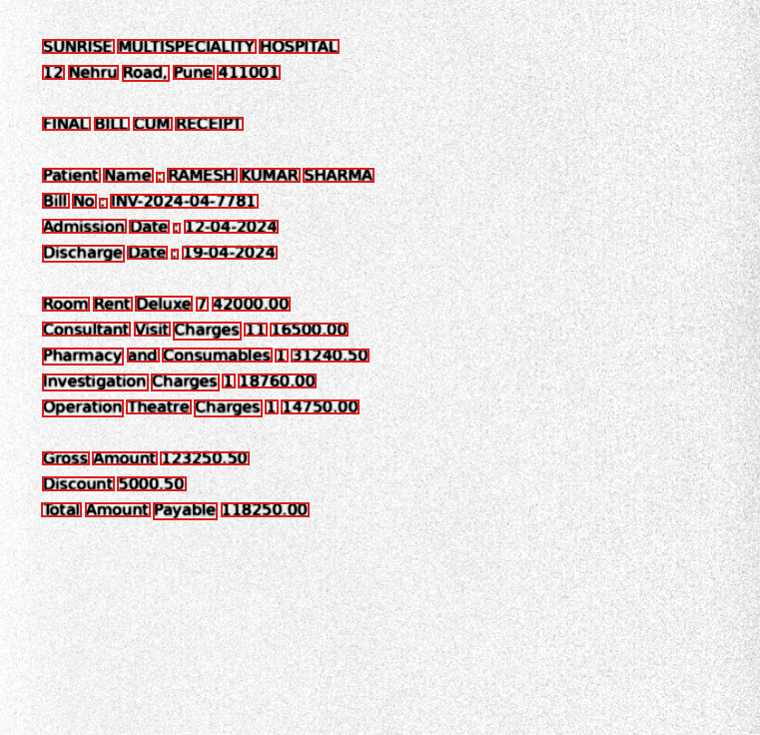

In [14]:
def draw_boxes(page, boxes, labels=(), width=2):
    """Return the page raster with boxes drawn on it, ready for show_image."""
    canvas = PILImage.fromarray(dp.Image.to_rgb(dp.Image.ensure_uint8(page.raster())))
    draw = ImageDraw.Draw(canvas)
    for i, box in enumerate(boxes):
        x0, y0, x1, y1 = box.to_pixels(page.raster_dpi)
        draw.rectangle([x0 - 1, y0 - 1, x1 + 1, y1 + 1], outline=(220, 30, 30), width=width)
        if i < len(labels):
            draw.text((x0, max(0, y0 - 12)), labels[i], fill=(200, 20, 20))
    return np.array(canvas)


page = doc.pages[0]
show_image(draw_boxes(page, [s.bbox for s in page.spans]),
           "every span the backend returned")

## 10. Normalising what the document assumes

Domain-independent, but not culture-independent. `1,23,456.78` is one lakh twenty-three
thousand, not one point two three, and `12-04-2024` is April in most of the world and
December in some of it. Getting these wrong is silent — you still get a number, just the
wrong one.

`read()` applies the normalisation pass by default; the parsers are also usable on their
own.

In [15]:
show_table(["raw text", "parsed", "note"], [
    ["1,23,456.78", dp.Text.parse_amount("1,23,456.78"), "Indian digit grouping"],
    ["1.234,56", dp.Text.parse_amount("1.234,56"), "European convention"],
    ["Rs. 1,18,250.00", dp.Text.parse_amount("Rs. 1,18,250.00"), "currency symbol stripped"],
    ["(2,500.00)", dp.Text.parse_amount("(2,500.00)"), "accounting negative"],
    ["12-04-2024", dp.Text.parse_date("12-04-2024", dayfirst=True), "day first"],
    ["12-04-2024", dp.Text.parse_date("12-04-2024", dayfirst=False), "month first"],
    ["19 Apr 2024", dp.Text.parse_date("19 Apr 2024"), "written month"],
    ["\u0967\u0968\u0969\u096a", dp.Text.normalize_digits("\u0967\u0968\u0969\u096a"), "Devanagari numerals"],
    ["11825O.OO", dp.Text.fix_ocr_confusions("11825O.OO", expect="numeric"), "OCR letter/digit confusion"],
    ["\u20b9 1,18,250", dp.Text.detect_currency("\u20b9 1,18,250"), "currency detection"],
])

raw text         parsed      note                      
---------------  ----------  --------------------------
1,23,456.78      123456.78   Indian digit grouping     
1.234,56         1234.56     European convention       
Rs. 1,18,250.00  118250.00   currency symbol stripped  
(2,500.00)       -2500.00    accounting negative       
12-04-2024       2024-04-12  day first                 
12-04-2024       2024-12-04  month first               
19 Apr 2024      2024-04-19  written month             
१२३४             1234        Devanagari numerals       
11825O.OO        118250.00   OCR letter/digit confusion
₹ 1,18,250       INR         currency detection        


## 11. Extraction

Schema in, typed fields out — each with a value, a confidence, and the rectangles it came
from.

The "model" here is `EchoClient` with a callable: a deterministic stand-in that reads the
prompt and copies values out of it. It ships in the library because every consuming project
needs the same thing to test its own schemas without a network or a bill. Swap it for
`dp.AnthropicClient(model="claude-sonnet-5")` and nothing else changes.

In [16]:
FIELD_PATTERNS = {
    "hospital_name": r"(SUNRISE[A-Z ]+?HOSPITAL)",
    "patient_name": r"Patient Name\s*:?\s*([A-Z][A-Z ]+)",
    "bill_number": r"Bill No\s*:?\s*(\S+)",
    "admission_date": r"Admission Date\s*:?\s*(\S+)",
    "discharge_date": r"Discharge Date\s*:?\s*(\S+)",
    "gross_amount": r"Gross Amount\s+(\S+)",
    "discount": r"Discount\s+(\S+)",
    "total": r"Total Amount Payable\s+(\S+)",
}


def grep_model(prompt):
    """A deterministic stand-in for an LLM: copy values straight out of the prompt."""
    out = {}
    for field, pattern in FIELD_PATTERNS.items():
        match = re.search(pattern, prompt)
        out[field] = match.group(1).strip() if match else None
    return json.dumps(out)


client = dp.EchoClient(response=grep_model)
result = dp.extract(doc, BILL_SCHEMA, context=CONTEXT, client=client, validators=VALIDATORS)

show_table(["field", "value", "python type", "confidence", "", "evidence"],
           [[name, str(f.value)[:32], type(f.value).__name__, "%.2f" % f.confidence,
             bar(f.confidence, 12),
             ("page %d" % f.evidence[0].page) if f.evidence else "-"]
            for name, f in result.fields.items()])
print()
print("valid: %s    mean confidence: %.2f    cost: %s"
      % (result.is_valid, result.mean_confidence, result.cost))

field           value                             python type  confidence                evidence
--------------  --------------------------------  -----------  ----------  ------------  --------
hospital_name   SUNRISE MULTISPECIALITY HOSPITAL  str          0.90        ###########.  page 0  
patient_name    RAMESH KUMAR SHARMA               str          0.90        ###########.  page 0  
bill_number     INV-2024-04-7781                  str          0.88        ###########.  page 0  
admission_date  2024-04-12                        date         0.90        ###########.  page 0  
discharge_date  2024-04-19                        date         0.90        ###########.  page 0  
gross_amount    123250.50                         Decimal      0.90        ###########.  page 0  
discount        5000.50                           Decimal      0.89        ###########.  page 0  
total           118250.00                         Decimal      0.90        ###########.  page 0  

valid: True    mean

## 12. What a confidence number is actually made of

A model's self-reported confidence is not a probability of correctness — it correlates with
fluency. A cleanly formatted hallucination scores high; a correct reading of a smudged digit
scores low. Shipping that to a reviewer labelled "confidence" is worse than shipping nothing,
because it will be believed.

`docpipe` fuses signals chosen to fail *independently*, in log-odds space rather than as a
weighted average — so one strong disagreement pulls the result down hard instead of being
averaged away by three agreeable signals. A signal of `None` means **absent**, not zero: an
engine that honestly declines to guess is not punished for it.

In [17]:
signal_names = ["text_support", "backend_conf", "page_quality", "format_match",
                "validation", "cross_read_agree"]

show_table(["field", "confidence"] + signal_names,
           [[name, "%.2f" % f.confidence] +
            [("%.2f" % f.signals[s]) if f.signals.get(s) is not None else "-"
             for s in signal_names]
            for name, f in result.fields.items()])
print()
print("default fusion weights:")
for key, weight in sorted(dp.DEFAULT_CONFIDENCE_WEIGHTS.items(), key=lambda kv: -kv[1]):
    print("  %-18s %.2f  %s" % (key, weight, bar(weight / 2.0, 16)))
print()
print("a confidence that has never been checked against labelled data is decoration --")
print("section 17 fits a calibrator that makes 0.9 mean 'right about nine times in ten'.")

field           confidence  text_support  backend_conf  page_quality  format_match  validation  cross_read_agree
--------------  ----------  ------------  ------------  ------------  ------------  ----------  ----------------
hospital_name   0.90        1.00          0.93          0.72          1.00          0.65        -               
patient_name    0.90        1.00          0.93          0.72          1.00          0.65        -               
bill_number     0.88        1.00          0.93          0.74          0.81          0.65        -               
admission_date  0.90        1.00          0.93          0.72          1.00          0.65        -               
discharge_date  0.90        1.00          0.93          0.72          1.00          0.65        -               
gross_amount    0.90        1.00          0.93          0.74          1.00          0.65        -               
discount        0.89        1.00          0.93          0.68          1.00          0.65        

## 13. When a rule fails

Now read the *unpreprocessed* page. The stub mangles digits, exactly as a real engine does
on a soft low-contrast scan, so the amounts stop reconciling.

Watch what happens without anyone writing routing logic: the validator fails, the failure
propagates into confidence fusion, the affected fields drop, and they surface in the review
queue.

In [18]:
raw_doc = dp.Ingest.ingest(dp.Image.encode_png(SCAN), filename="bill.png", dpi=150)
raw_doc = dp.preprocess(raw_doc, policy=dp.Policies.no_policy)   # measure, correct nothing
raw_doc = dp.read(raw_doc, backend="stub-ocr")
raw_doc = dp.Text.normalize_document(raw_doc, in_place=True)

print("what the reader saw on the uncorrected page:")
for line in raw_doc.pages[0].lines()[-3:]:
    print("  " + line)
print()

broken = dp.extract(raw_doc, BILL_SCHEMA, context=CONTEXT, client=client, validators=VALIDATORS)

show_table(["field", "clean page", "conf", "uncorrected page", "conf", "change"],
           [[name,
             str(result.fields[name].value)[:22], "%.2f" % result.fields[name].confidence,
             str(broken.fields[name].value)[:22], "%.2f" % broken.fields[name].confidence,
             "%+.2f" % (broken.fields[name].confidence - result.fields[name].confidence)]
            for name in result.fields])
print()
print("valid: %s" % broken.is_valid)
for issue in broken.issues:
    print("  issue: %s  (fields: %s)" % (issue.message, ", ".join(issue.fields)))
print()
print("review queue -- everything below 0.75:")
for f in broken.low_confidence(0.75):
    live = dict((k, round(v, 2)) for k, v in f.signals.items() if v is not None)
    print("  %-16s conf=%.2f  signals=%s" % (f.name, f.confidence, live))

what the reader saw on the uncorrected page:
  Gross Amount l2325O.5O
  Discount 5OOO.5O
  Total Amount Payable ll825O.OO

field           clean page              conf  uncorrected page        conf  change
--------------  ----------------------  ----  ----------------------  ----  ------
hospital_name   SUNRISE MULTISPECIALIT  0.90  SUNRISE MULTISPECIALIT  0.80  -0.09 
patient_name    RAMESH KUMAR SHARMA     0.90  RAMESH KUMAR SHARMA     0.80  -0.09 
bill_number     INV-2024-04-7781        0.88  INV-2O24-O4-778l        0.78  -0.10 
admission_date  2024-04-12              0.90  None                    0.00  -0.90 
discharge_date  2024-04-19              0.90  None                    0.00  -0.90 
gross_amount    123250.50               0.90  2325                    0.10  -0.80 
discount        5000.50                 0.89  5                       0.10  -0.80 
total           118250.00               0.90  825                     0.10  -0.80 

valid: False
  issue: gross 2325 minus discoun

## 14. Evidence on the page

Six months later somebody disputes a figure. "The model said so" is not an answer. Every
field carries the rectangles it came from, recorded at read time — because provenance is
recoverable then and unrecoverable afterwards.

8 of 8 fields located on this page
field           value                       rectangle (pt)     
--------------  --------------------------  -------------------
hospital_name   SUNRISE MULTISPECIALITY HO  19, 17 -> 146, 22  
patient_name    RAMESH KUMAR SHARMA         68, 73 -> 161, 78  
bill_number     INV-2024-04-7781            43, 84 -> 111, 89  
admission_date  2024-04-12                  75, 95 -> 120, 100 
discharge_date  2024-04-19                  74, 106 -> 119, 111
gross_amount    123250.50                   70, 195 -> 107, 200
discount        5000.50                     51, 206 -> 80, 211 
total           118250.00                   96, 217 -> 133, 222
where each extracted value came from  --  761 x 736 px


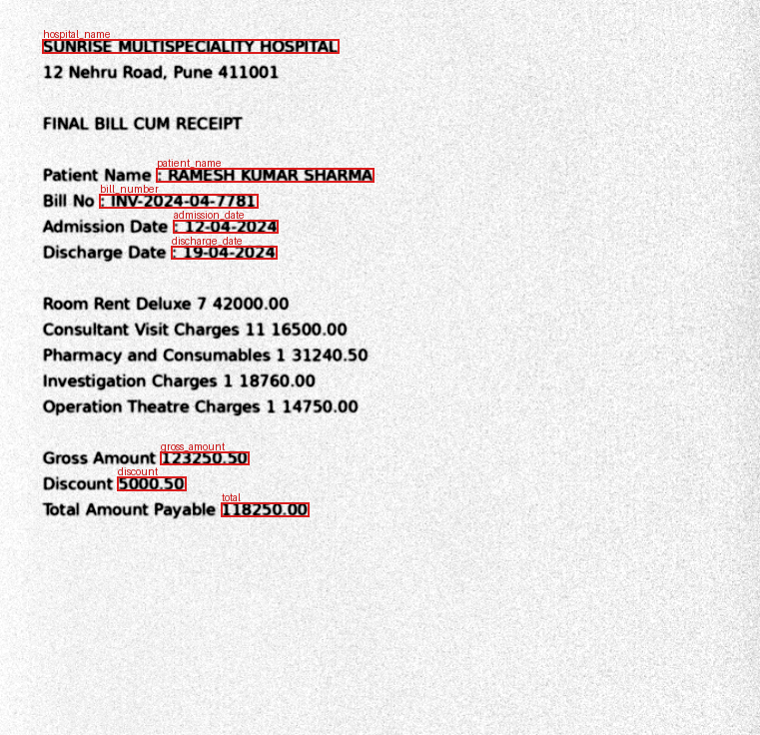

In [19]:
page = doc.pages[0]
boxes, labels = [], []
for name, f in result.fields.items():
    for box in f.evidence:
        if box.page == page.index:
            boxes.append(box)
            labels.append(name)

print("%d of %d fields located on this page" % (len(boxes), len(result.fields)))
show_table(["field", "value", "rectangle (pt)"],
           [[labels[i], str(result.fields[labels[i]].value)[:26],
             "%.0f, %.0f -> %.0f, %.0f" % (b.x0, b.y0, b.x1, b.y1)]
            for i, b in enumerate(boxes)])
show_image(draw_boxes(page, boxes, labels), "where each extracted value came from")

## 15. No model at all

Air-gapped deployment, a compliance rule, or simply a form whose layout never moves. Anchor
on the printed label and read the value beside it. No model, no network — and you still get
the evidence rectangle.

In [20]:
rules = [
    dp.FieldRule(name="bill_number", label=r"Bill No", direction="right"),
    dp.FieldRule(name="admission_date", label=r"Admission Date", direction="right",
                 type_name="date"),
    dp.FieldRule(name="patient_name", label=r"Patient Name", direction="right"),
    dp.FieldRule(name="total", label=r"Total Amount Payable", direction="right",
                 value_pattern=r"([\d,]+\.\d{2})", type_name="number"),
]

by_rule = dp.extract_with_rules(doc, rules)
show_table(["field", "value", "type", "method", "evidence", "warnings"],
           [[name, str(f.value)[:28], type(f.value).__name__, f.method,
             "yes" if f.evidence else "-", "; ".join(f.warnings) or "-"]
            for name, f in by_rule.items()])

field           value                type     method  evidence  warnings
--------------  -------------------  -------  ------  --------  --------
bill_number     INV-2024-04-7781     str      rules   yes       -       
admission_date  2024-04-12           date     rules   yes       -       
patient_name    RAMESH KUMAR SHARMA  str      rules   yes       -       
total           118250.00            Decimal  rules   yes       -       


## 16. Token and cost accounting

`PRICING` ships **empty**, on purpose. Token counts are always tracked; the monetary amount
reads `0.00` and warns until you register what your account actually pays. A wrong price is
worse than a missing one, because it produces a plausible budget report that nobody
rechecks.

In [21]:
before = dp.Pricing.price_tokens("claude-sonnet-5", 12000, 800)
dp.Pricing.set_pricing("claude-sonnet-5", input_per_mtok=3.00, output_per_mtok=15.00)
after = dp.Pricing.price_tokens("claude-sonnet-5", 12000, 800)

show_table(["", "input tokens", "output tokens", "amount"],
           [["before set_pricing", before.input_tokens, before.output_tokens,
             "%.4f %s" % (before.amount, before.currency)],
            ["after set_pricing", after.input_tokens, after.output_tokens,
             "%.4f %s" % (after.amount, after.currency)]])
print()
tracker = dp.CostTracker()
tracker.add(after, backend="vlm:claude")
tracker.add(dp.Cost(calls=1), backend="stub-ocr")
print("per-backend tracking: %s" % tracker.to_dict())
print()
print("a hard ceiling is available too:  dp.read(doc, budget=2.50)  ->  BudgetExceeded")

                    input tokens  output tokens  amount    
------------------  ------------  -------------  ----------
before set_pricing  12000         800            0.0000 USD
after set_pricing   12000         800            0.0480 USD

per-backend tracking: {'total': {'currency': 'USD', 'amount': 0.048, 'input_tokens': 12000, 'output_tokens': 800, 'calls': 2, 'wasted_calls': 0}, 'by_backend': {'vlm:claude': {'currency': 'USD', 'amount': 0.048, 'input_tokens': 12000, 'output_tokens': 800, 'calls': 1, 'wasted_calls': 0}, 'stub-ocr': {'currency': 'USD', 'amount': 0.0, 'input_tokens': 0, 'output_tokens': 0, 'calls': 1, 'wasted_calls': 0}}, 'budget': None}

a hard ceiling is available too:  dp.read(doc, budget=2.50)  ->  BudgetExceeded


## 17. Did preprocessing actually help?

Everything above is anecdote until it is measured. Two pipelines, identical except that one
skips preprocessing, run against a labelled dataset. This is the component to build first in
any extraction project — without it, "did that change help?" is answered by eyeballing a
handful of documents, which is not a measurement.

The dataset is two documents beside their ground truth: `<stem>.png` next to `<stem>.json`.

In [22]:
dataset = os.path.join(tempfile.mkdtemp(prefix="docpipe-eval-"), "bills")
os.makedirs(dataset)

TRUTH = {
    "hospital_name": "SUNRISE MULTISPECIALITY HOSPITAL",
    "patient_name": "RAMESH KUMAR SHARMA",
    "bill_number": "INV-2024-04-7781",
    "admission_date": "2024-04-12",
    "discharge_date": "2024-04-19",
    "gross_amount": "123250.50",
    "discount": "5000.50",
    "total": "118250.00",
}

cases = [("bill_harsh", SCAN, ["degraded"]),
         ("bill_mild", dp.Image.resize_image(dp.Image.gaussian_blur(CLEAN, 0.6), scale=0.8),
          ["clean"])]
for case_id, image, tags in cases:
    dp.Image.save_image(image, os.path.join(dataset, "%s.png" % case_id))
    with open(os.path.join(dataset, "%s.json" % case_id), "w") as fh:
        json.dump({"truth": TRUTH, "tags": tags}, fh)

suite = dp.EvalSuite.from_dir(dataset)

# Tell the harness which fields are numeric, so "118250.00" and Decimal("118250.0")
# compare with a tolerance instead of as strings.
suite.field_types = dict((f.name, f.type_name) for f in adapter.fields)

show_table(["case", "tags", "truth fields", "document"],
           [[c.case_id, ", ".join(c.tags), len(c.truth), os.path.basename(c.path)]
            for c in suite.cases])

case        tags      truth fields  document      
----------  --------  ------------  --------------
bill_harsh  degraded  8             bill_harsh.png
bill_mild   clean     8             bill_mild.png 


### Run both pipelines

A `Pipeline` is the whole thing as data — policy, router, backend, schema, client,
validators — which is what makes it reproducible and comparable.

In [23]:
common = dict(backend="stub-ocr", schema=BILL_SCHEMA, context=CONTEXT,
              client=dp.EchoClient(response=grep_model), validators=VALIDATORS,
              router=None)

baseline = dp.Pipeline(name="baseline", policy=dp.Policies.no_policy, **common)
adaptive = dp.Pipeline(name="adaptive", policy=dp.Policies.default_policy, **common)

report = suite.run({"baseline": baseline, "adaptive": adaptive})
print(report.summary())

eval suite: bills   cases: 2   2026-08-12T03:31:15Z

  metric                      adaptive      baseline
  --------------------------------------------------
  field_exact                   1.0000        0.2500
  field_fuzzy                   1.0000        0.3461
  numeric_tolerance             1.0000        0.0000
  field_recall                  1.0000        0.7500
  evidence_coverage             1.0000        0.5000
  confidence_calibration        0.1053        0.1837
  brier                         0.0111        0.0902
  cost_per_doc                  0.0000        0.0000
  latency_p50                 875.8645      376.6463
  latency_p95                 914.7085      450.8679
  error_rate                    0.0000        0.0000


### Read the report, not just the headline

`by_field` says *which* fields moved — an average that improves while your money field
degrades is a regression wearing a disguise. `by_page_quality` is the one to watch hardest:
a change that lifts the mean by improving pages that already worked, leaving the degraded
ones exactly as broken, has not solved the problem it was meant to solve.

In [24]:
base_fields = report.by_field("baseline")
adapt_fields = report.by_field("adaptive")

print("per-field accuracy (n = %d cases each):" % len(suite))
show_table(["field", "baseline", "", "adaptive", "", "mean conf (adaptive)"],
           [[name,
             "%.2f" % base_fields[name]["correct"], bar(base_fields[name]["correct"], 10),
             "%.2f" % adapt_fields[name]["correct"], bar(adapt_fields[name]["correct"], 10),
             "%.2f" % adapt_fields[name]["mean_confidence"]]
            for name in sorted(adapt_fields)])

print()
print("by page quality -- the split that catches a change which only helped the easy pages:")
rows = []
for pipeline in ("baseline", "adaptive"):
    for verdict, stats in sorted(report.by_page_quality(pipeline).items()):
        rows.append([pipeline, verdict, stats["n"], "%.2f" % stats["correct"],
                     "%.2f" % stats["mean_confidence"]])
show_table(["pipeline", "page verdict", "fields", "correct", "mean conf"], rows)

print()
delta = report.compare("baseline", "adaptive")
show_table(["metric", "baseline", "adaptive", "delta"],
           [[metric, "%.4f" % delta["baseline_metrics"][metric],
             "%.4f" % delta["candidate_metrics"][metric], "%+.4f" % value]
            for metric, value in sorted(delta["deltas"].items())
            if not metric.startswith("latency")])
print()
print("fields that improved:  %s" % ", ".join(r["field"] for r in delta["improvements"]))
print("fields that regressed: %s" % (", ".join(r["field"] for r in delta["regressions"]) or "none"))

per-field accuracy (n = 2 cases each):
field           baseline              adaptive              mean conf (adaptive)
--------------  --------  ----------  --------  ----------  --------------------
admission_date  0.00      ..........  1.00      ##########  0.90                
bill_number     0.00      ..........  1.00      ##########  0.88                
discharge_date  0.00      ..........  1.00      ##########  0.90                
discount        0.00      ..........  1.00      ##########  0.90                
gross_amount    0.00      ..........  1.00      ##########  0.90                
hospital_name   1.00      ##########  1.00      ##########  0.90                
patient_name    1.00      ##########  1.00      ##########  0.90                
total           0.00      ..........  1.00      ##########  0.90                

by page quality -- the split that catches a change which only helped the easy pages:
pipeline  page verdict  fields  correct  mean conf
--------  ----

### Gate CI on it, and close the confidence loop

`regression_vs` compares against a saved report and is what makes a pipeline change
reviewable. The CLI form exits non-zero, so it drops straight into a workflow file:

```bash
docpipe eval datasets/bills --schema schema.json \
        --report reports/run.json --baseline reports/release.json --tolerance 0.01
```

Fitting a calibrator on the report is the step that turns confidence from decoration into a
number you can set a threshold against.

In [25]:
path = os.path.join(dataset, "report.json")
report.save(path)
reloaded = dp.EvalReport.load(path)
print("saved and reloaded: pipelines=%s" % reloaded.pipelines())

regressed = report.regression_vs(reloaded, pipeline="adaptive", tolerance=0.01)
print("checked against the saved baseline: %s"
      % ("regressed -- CI would fail here" if regressed.get("regressed") else "no regression"))
print()

print("is a 0.9 right 90 percent of the time?")
show_table(["confidence bin", "fields", "mean confidence", "actual accuracy", "gap"],
           [["%.2f - %.2f" % (b["bin_low"], b["bin_high"]), int(b["count"]),
             "%.2f" % b["mean_confidence"], "%.2f" % b["accuracy"], "%+.2f" % b["gap"]]
            for b in report.confidence_curve("adaptive", bins=4) if b["count"]])
print()

calibrator = report.fit_calibrator("adaptive", kind="platt")
print("fitted %r" % calibrator)
show_table(["raw confidence", "calibrated"],
           [["%.2f" % s, "%.2f" % calibrator.predict(s)] for s in (0.3, 0.5, 0.7, 0.9)])
print()
print("pass it straight back in:")
print("  dp.extract(doc, schema, client=client, calibrator=calibrator)")
print()
print("worst cases in the baseline, to look at first:")
for case_id, score in report.worst_cases("baseline", limit=3):
    print("  %-14s %.2f" % (case_id, score))

saved and reloaded: pipelines=['adaptive', 'baseline']
checked against the saved baseline: no regression

is a 0.9 right 90 percent of the time?
confidence bin  fields  mean confidence  actual accuracy  gap  
--------------  ------  ---------------  ---------------  -----
0.75 - 1.00     16      0.89             1.00             +0.11

fitted PlattCalibrator(a=1.2619, b=0.1319, n=16)
raw confidence  calibrated
--------------  ----------
0.30            0.28      
0.50            0.53      
0.70            0.77      
0.90            0.95      

pass it straight back in:
  dp.extract(doc, schema, client=client, calibrator=calibrator)

worst cases in the baseline, to look at first:
  bill_harsh     0.25
  bill_mild      0.25


## 18. Everything is serialisable

Ops, documents, pipelines and reports all round-trip through JSON. That is what makes an
experiment reproducible six months later, and what lets a result carry the exact
configuration that produced it.

In [26]:
doc_path = os.path.join(dataset, "document.json")
doc.save_json(doc_path)
restored = dp.Document.load_json(doc_path)

show_table(["artefact", "round-trips via", "check"], [
    ["Op", "op.to_dict / op_from_dict",
     repr(dp.op_from_dict(dp.Ops.deskew().to_dict()))],
    ["Document", "save_json / load_json",
     "%d pages, %d spans, %d chars" % (len(restored.pages), len(restored.spans()),
                                       restored.char_count)],
    ["Extraction", "result.to_dict", "%d keys" % len(result.to_dict())],
    ["EvalReport", "report.save / load", "%d pipelines" % len(reloaded.pipelines())],
])
print()
print("how the winning pipeline was configured -- attach this to a result and a")
print("disagreement six months from now is settled by looking it up:")
for key, value in sorted(adaptive.to_dict().items()):
    print("  %-16s %s" % (key, str(value)[:64]))

artefact    round-trips via            check                                                               
----------  -------------------------  --------------------------------------------------------------------
Op          op.to_dict / op_from_dict  Op(deskew, angle=None, max_angle=15.0, method='auto', min_angle=0.4)
Document    save_json / load_json      1 pages, 63 spans, 380 chars                                        
Extraction  result.to_dict             9 keys                                                              
EvalReport  report.save / load         2 pipelines                                                         

how the winning pipeline was configured -- attach this to a result and a
disagreement six months from now is settled by looking it up:
  backend          stub-ocr
  budget           None
  calibrator       None
  client           echo
  docpipe_version  0.1.0
  name             adaptive
  normalize        True
  policy           default_policy
  ren

## Where to go next

- **[How-to-use.md](../How-to-use.md)** — the same ground as a problem-first guide: 17 real
  situations, each with the code that solves it.
- **[README.md](../README.md)** — why the library is shaped this way. The *Scope boundary*
  and *Honest limitations* sections are the authority on what belongs in core.
- **[API reference](https://utkarsh5026.github.io/Docpipe/)** — every class and function,
  generated from the source itself.
- **[hospital_bill.py](hospital_bill.py)** — this notebook's script form, runnable with
  `python examples/hospital_bill.py`.
- **[tests/](../tests/)** — roughly 660 tests, all offline, and the most exhaustive usage
  documentation there is.

**What a real project changes from here:** point `Ingest.ingest` at your own file, swap
`StubOCR` for `"tesseract"` or `"paddle"`, swap `EchoClient` for
`dp.AnthropicClient(model="claude-sonnet-5")`, and replace the schema and validators with
your own. Everything between those two ends is what the library is for.